# Disney Visitor Data Analysis Notebook

This notebook performs a complete cleaning, analysis, and visualization workflow for the Disney visitor dataset.

## Contents
1. Data Loading and Preview
2. Data Cleaning
3. Exploratory Data Analysis (EDA)
4. Feature Engineering
5. Data Visualization
6. Data Export

## 1. Data Loading and Preview

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load data
df = pd.read_csv('../data/raw/disney_attendance.csv')
df['date'] = pd.to_datetime(df['date'])

print(f"Dataset shape: {df.shape}")
print(f"\nThe dataset contains {len(df)} records, {len(df.columns)} features")

Dataset shape: (2557, 15)

The dataset contains 2557 records, 15 features


In [3]:
# Preview the first few rows
df.head(10)

,date,year,month,day,day_of_week,day_of_year,week_of_year,is_weekend,is_holiday,is_peak_season,is_school_holiday,temperature,rain_probability,is_rainy,visitors
0,2018-01-01,2018,1,1,0,1,1,0,1,0,0,64,0.15,0,45221
1,2018-01-02,2018,1,2,1,2,1,0,0,0,0,65,0.15,0,45595
2,2018-01-03,2018,1,3,2,3,1,0,0,0,0,64,0.15,1,52429
3,2018-01-04,2018,1,4,3,4,1,0,0,0,0,68,0.15,0,38259
4,2018-01-05,2018,1,5,4,5,1,0,0,0,0,69,0.15,0,41785
5,2018-01-06,2018,1,6,5,6,1,1,0,0,0,60,0.15,0,50801
6,2018-01-07,2018,1,7,6,7,1,1,0,0,0,62,0.15,0,45307
7,2018-01-08,2018,1,8,0,8,2,0,0,0,0,61,0.15,0,34074
8,2018-01-09,2018,1,9,1,9,2,0,0,0,0,62,0.15,1,31285
9,2018-01-10,2018,1,10,2,10,2,0,0,0,0,69,0.15,0,33918


In [4]:
# Check data types
print("Data types:")
print(df.dtypes)

Data types:
date                 datetime64[ns]
year                          int64
month                         int64
day                           int64
day_of_week                   int64
day_of_year                   int64
week_of_year                  int64
is_weekend                    int64
is_holiday                    int64
is_peak_season                int64
is_school_holiday             int64
temperature                   int64
rain_probability            float64
is_rainy                      int64
visitors                      int64
dtype: object


In [5]:
# Basic descriptive statistics
df.describe()

,date,year,month,day,day_of_week,day_of_year,week_of_year,is_weekend,is_holiday,is_peak_season,is_school_holiday,temperature,rain_probability,is_rainy,visitors
count,2557,2557.000000,2557.000000,2557.000000,2557.000000,2557.000000,2557.000000,2557.000000,2557.000000,2557.000000,2557.000000,2557.000000,2557.000000,2557.000000,2557.000000
mean,2021-07-02 00:00:00,2021.000782,6.522487,15.730935,2.998045,183.143136,26.552601,0.285491,0.032851,0.503715,0.481815,77.128666,0.297223,0.296050,45183.463825
min,2018-01-01 00:00:00,2018.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,60.000000,0.150000,0.000000,6065.000000
25%,2019-10-02 00:00:00,2019.000000,4.000000,8.000000,1.000000,92.000000,14.000000,0.000000,0.000000,0.000000,0.000000,69.000000,0.180000,0.000000,29436.000000
50%,2021-07-02 00:00:00,2021.000000,7.000000,16.000000,3.000000,183.000000,27.000000,0.000000,0.000000,1.000000,0.000000,77.000000,0.250000,0.000000,43383.000000
75%,2023-04-02 00:00:00,2023.000000,10.000000,23.000000,5.000000,274.000000,40.000000,1.000000,0.000000,1.000000,1.000000,85.000000,0.450000,1.000000,59655.000000
max,2024-12-31 00:00:00,2024.000000,12.000000,31.000000,6.000000,366.000000,53.000000,1.000000,1.000000,1.000000,1.000000,93.000000,0.550000,1.000000,80000.000000
std,NaN,2.000587,3.449499,8.802361,2.000879,105.469618,15.065665,0.451736,0.178281,0.500084,0.499767,9.027576,0.141886,0.456603,19794.452140


## 2. Data Cleaning

In [6]:
# Check missing values
print("Missing value summary:")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0] if missing_values.sum() > 0 else "No missing values")

Missing value summary:
No missing values


In [7]:
# Check duplicate rows
duplicates = df.duplicated().sum()
print(f"Number of duplicate records: {duplicates}")

if duplicates > 0:
    df = df.drop_duplicates()
    print(f"Removed {duplicates} duplicate records")

Number of duplicate records: 0


In [8]:
# Check outliers - using the IQR method
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

outliers, lower, upper = detect_outliers_iqr(df, 'visitors')
print(f"Visitor count outlier summary:")
print(f"  - Lower bound: {lower:.0f}")
print(f"  - Upper bound: {upper:.0f}")
print(f"  - Number of outliers: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")

Visitor count outlier summary:
  - Lower bound: -15892
  - Upper bound: 104984
  - Number of outliers: 0 (0.00%)


In [9]:
# View outlier details (extreme values may come from special events)
if len(outliers) > 0:
    print("Outlier date distribution:")
    print(outliers[['date', 'visitors', 'is_holiday', 'is_peak_season']].head(20))

In [10]:
# Data type conversion and validation
# Ensure the date format is correct
df['date'] = pd.to_datetime(df['date'])

# Ensure numeric columns are integers
int_columns = ['visitors', 'temperature', 'year', 'month', 'day', 'day_of_week', 'day_of_year', 'week_of_year']
for col in int_columns:
    if col in df.columns:
        df[col] = df[col].astype(int)

# Ensure boolean columns are stored as integers
bool_columns = ['is_weekend', 'is_holiday', 'is_peak_season', 'is_school_holiday', 'is_rainy']
for col in bool_columns:
    if col in df.columns:
        df[col] = df[col].astype(int)

print("Data type conversion completed!")

Data type conversion completed!


## 3. Exploratory Data Analysis (EDA)

In [11]:
# Summarize visitors by year
yearly_stats = df.groupby('year')['visitors'].agg(['mean', 'median', 'std', 'min', 'max', 'sum'])
yearly_stats.columns = ['Mean', 'Median', 'Std', 'Min', 'Max', 'Total visitors']
print("Annual visitor statistics:")
print(yearly_stats.round(0))

Annual visitor statistics:
         Mean   Median      Std    Min    Max  Total visitors
year                                                         
2018  53547.0  51893.0  17125.0  21447  80000        19544721
2019  54711.0  53506.0  17262.0  19092  80000        19969404
2020  19351.0  18466.0   7382.0   6065  49753         7082626
2021  36424.0  33422.0  13975.0  11585  80000        13294824
2022  46743.0  43230.0  17023.0  16809  80000        17061290
2023  51962.0  49012.0  17245.0  17399  80000        18966300
2024  53593.0  51221.0  17132.0  22079  80000        19614952


In [12]:
# Summarize visitors by month
monthly_stats = df.groupby('month')['visitors'].agg(['mean', 'median', 'std']).round(0)
monthly_stats.columns = ['Average visitors', 'Median', 'Std']
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', '1Jan', '1Feb']
monthly_stats.index = month_names
print("\nMonthly visitor statistics:")
print(monthly_stats)


Monthly visitor statistics:
      Average visitors   Median      Std
Jan            34983.0  34893.0  11876.0
Feb            32045.0  32432.0  11102.0
Mar            59315.0  62669.0  18929.0
Apr            61930.0  68160.0  18827.0
May            44270.0  45008.0  14838.0
Jun            54089.0  54788.0  18426.0
Jul            59796.0  61735.0  18573.0
Aug            48126.0  48196.0  16433.0
Sep            25525.0  26005.0   9079.0
Oct            29032.0  29265.0   9975.0
1Jan           38480.0  38894.0  14015.0
1Feb           53438.0  52889.0  19018.0


In [13]:
# Summarize visitors by weekday
weekday_stats = df.groupby('day_of_week')['visitors'].agg(['mean', 'median', 'std']).round(0)
weekday_stats.columns = ['Average visitors', 'Median', 'Std']
weekday_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_stats.index = weekday_names
print("\nWeekday visitor statistics:")
print(weekday_stats)


Weekday visitor statistics:
           Average visitors   Median      Std
Monday              40047.0  37452.0  17719.0
Tuesday             37233.0  34940.0  16129.0
Wednesday           40092.0  38437.0  17640.0
Thursday            42055.0  39444.0  18396.0
Friday              48507.0  46141.0  19685.0
Saturday            54960.0  55467.0  20518.0
Sunday              53425.0  51903.0  20412.0


In [14]:
# Holiday vs. non-holiday comparison
holiday_comparison = df.groupby('is_holiday')['visitors'].agg(['mean', 'median', 'count'])
holiday_comparison.index = ['Non-holiday', 'Holiday']
holiday_comparison.columns = ['Average visitors', 'Median', 'Days']
print("\nHoliday vs Non-holiday:")
print(holiday_comparison.round(0))


Holiday vs Non-holiday:
             Average visitors   Median  Days
Non-holiday           45290.0  43589.0  2473
Holiday               42040.0  39959.0    84


In [15]:
# Weekend vs. weekday comparison
weekend_comparison = df.groupby('is_weekend')['visitors'].agg(['mean', 'median', 'count'])
weekend_comparison.index = ['Weekday', 'Weekend']
weekend_comparison.columns = ['Average visitors', 'Median', 'Days']
print("\nWeekend vs Weekday:")
print(weekend_comparison.round(0))


Weekend vs Weekday:
         Average visitors   Median  Days
Weekday           41584.0  39622.0  1827
Weekend           54193.0  53483.0   730


In [16]:
# Correlation analysis
numeric_columns = ['visitors', 'month', 'day_of_week', 'is_weekend', 'is_holiday', 
                   'is_peak_season', 'is_school_holiday', 'temperature', 'rain_probability', 'is_rainy']
correlation_matrix = df[numeric_columns].corr()

print("\nCorrelation with visitor counts:")
visitors_corr = correlation_matrix['visitors'].sort_values(ascending=False)
print(visitors_corr)


Correlation with visitor counts:
visitors             1.000000
is_peak_season       0.555462
is_school_holiday    0.547934
day_of_week          0.303186
is_weekend           0.287755
temperature          0.105185
rain_probability     0.082289
is_rainy             0.017626
is_holiday          -0.029273
month               -0.073393
Name: visitors, dtype: float64


## 4. Feature Engineering

In [17]:
# Add additional time-based features
df['quarter'] = df['date'].dt.quarter
df['is_month_start'] = df['date'].dt.is_month_start.astype(int)
df['is_month_end'] = df['date'].dt.is_month_end.astype(int)

# Add season features
def get_season(month):
    if month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    elif month in [9, 10, 11]:
        return 'Fall'
    else:
        return 'Winter'

df['season'] = df['month'].apply(get_season)

# Add lag features (previous day's visitors)
df['visitors_lag1'] = df['visitors'].shift(1)
df['visitors_lag7'] = df['visitors'].shift(7)  # same day of the previous week

# Add moving-average features
df['visitors_ma7'] = df['visitors'].rolling(window=7).mean()
df['visitors_ma30'] = df['visitors'].rolling(window=30).mean()

# Fill NaN values
df['visitors_lag1'] = df['visitors_lag1'].fillna(df['visitors'].mean())
df['visitors_lag7'] = df['visitors_lag7'].fillna(df['visitors'].mean())
df['visitors_ma7'] = df['visitors_ma7'].fillna(df['visitors'].mean())
df['visitors_ma30'] = df['visitors_ma30'].fillna(df['visitors'].mean())

print("Feature engineering completed!")
print(f"Added features: quarter, is_month_start, is_month_end, season, visitors_lag1, visitors_lag7, visitors_ma7, visitors_ma30")

Feature engineering completed!
Added features: quarter, is_month_start, is_month_end, season, visitors_lag1, visitors_lag7, visitors_ma7, visitors_ma30


In [18]:
# View the dataset after adding features
df.head()

,date,year,month,day,day_of_week,day_of_year,week_of_year,is_weekend,is_holiday,is_peak_season,...,is_rainy,visitors,quarter,is_month_start,is_month_end,season,visitors_lag1,visitors_lag7,visitors_ma7,visitors_ma30
0,2018-01-01,2018,1,1,0,1,1,0,1,0,...,0,45221,1,1,0,Winter,45183.463825,45183.463825,45183.463825,45183.463825
1,2018-01-02,2018,1,2,1,2,1,0,0,0,...,0,45595,1,0,0,Winter,45221.000000,45183.463825,45183.463825,45183.463825
2,2018-01-03,2018,1,3,2,3,1,0,0,0,...,1,52429,1,0,0,Winter,45595.000000,45183.463825,45183.463825,45183.463825
3,2018-01-04,2018,1,4,3,4,1,0,0,0,...,0,38259,1,0,0,Winter,52429.000000,45183.463825,45183.463825,45183.463825
4,2018-01-05,2018,1,5,4,5,1,0,0,0,...,0,41785,1,0,0,Winter,38259.000000,45183.463825,45183.463825,45183.463825


## 5. Data Visualization

In [19]:
# Set figure size
fig_size = (14, 6)

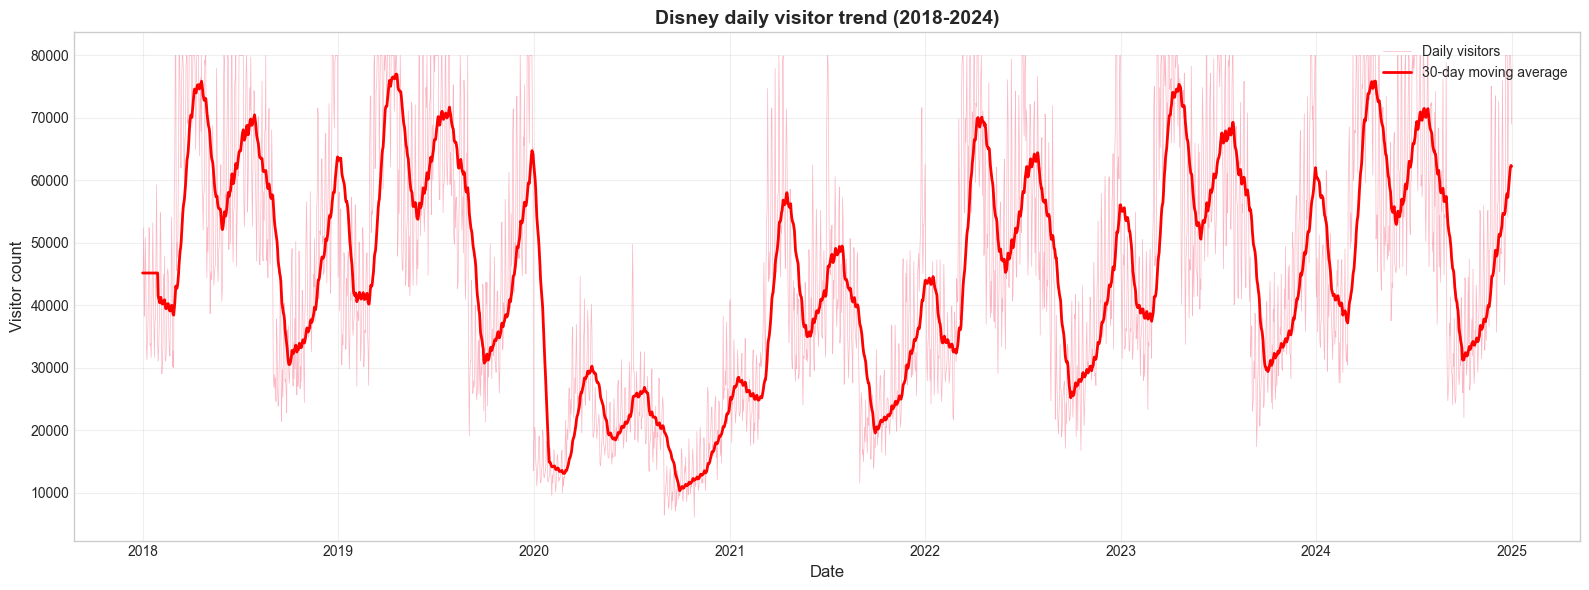

In [20]:
# 1. Visitor count time series
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(df['date'], df['visitors'], alpha=0.5, linewidth=0.5, label='Daily visitors')
ax.plot(df['date'], df['visitors_ma30'], color='red', linewidth=2, label='30-day moving average')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Visitor count', fontsize=12)
ax.set_title('Disney daily visitor trend (2018-2024)', fontsize=14, fontweight='bold')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../images/visitors_time_series.png', dpi=150, bbox_inches='tight')
plt.show()

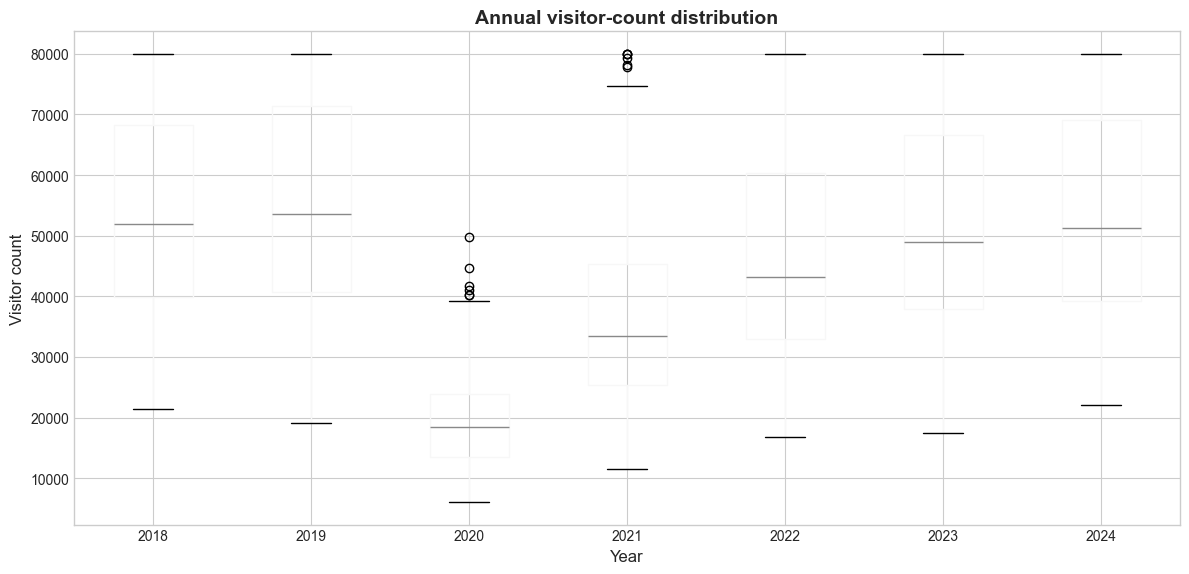

In [21]:
# 2. Annual visitor-count box plot
fig, ax = plt.subplots(figsize=(12, 6))
df.boxplot(column='visitors', by='year', ax=ax)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Visitor count', fontsize=12)
ax.set_title('Annual visitor-count distribution', fontsize=14, fontweight='bold')
plt.suptitle('')  # Remove the auto-generated title
plt.tight_layout()
plt.savefig('../images/yearly_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

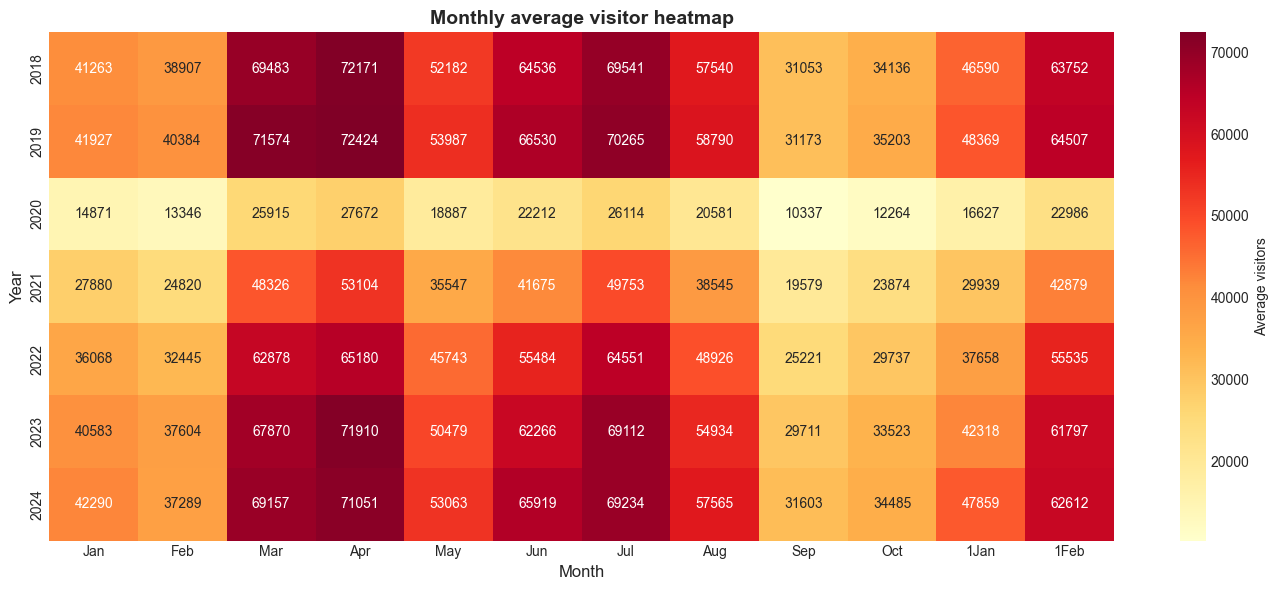

In [22]:
# 3. Monthly visitor-count heatmap
monthly_avg = df.groupby(['year', 'month'])['visitors'].mean().unstack()
monthly_avg.columns = month_names

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(monthly_avg, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax, 
            cbar_kws={'label': 'Average visitors'})
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Year', fontsize=12)
ax.set_title('Monthly average visitor heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/monthly_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

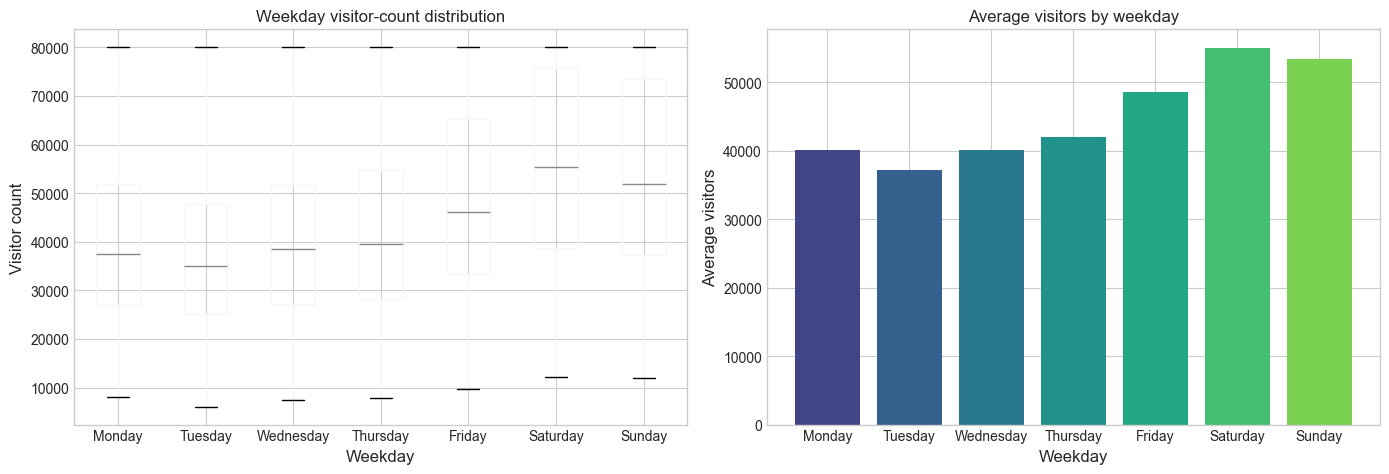

In [23]:
# 4. Weekday visitor-count distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot
df.boxplot(column='visitors', by='day_of_week', ax=axes[0])
axes[0].set_xticklabels(weekday_names)
axes[0].set_xlabel('Weekday', fontsize=12)
axes[0].set_ylabel('Visitor count', fontsize=12)
axes[0].set_title('Weekday visitor-count distribution')

# Bar chart
weekday_means = df.groupby('day_of_week')['visitors'].mean()
colors = plt.cm.viridis(np.linspace(0.2, 0.8, 7))
axes[1].bar(weekday_names, weekday_means, color=colors)
axes[1].set_xlabel('Weekday', fontsize=12)
axes[1].set_ylabel('Average visitors', fontsize=12)
axes[1].set_title('Average visitors by weekday')

plt.suptitle('')
plt.tight_layout()
plt.savefig('../images/weekday_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

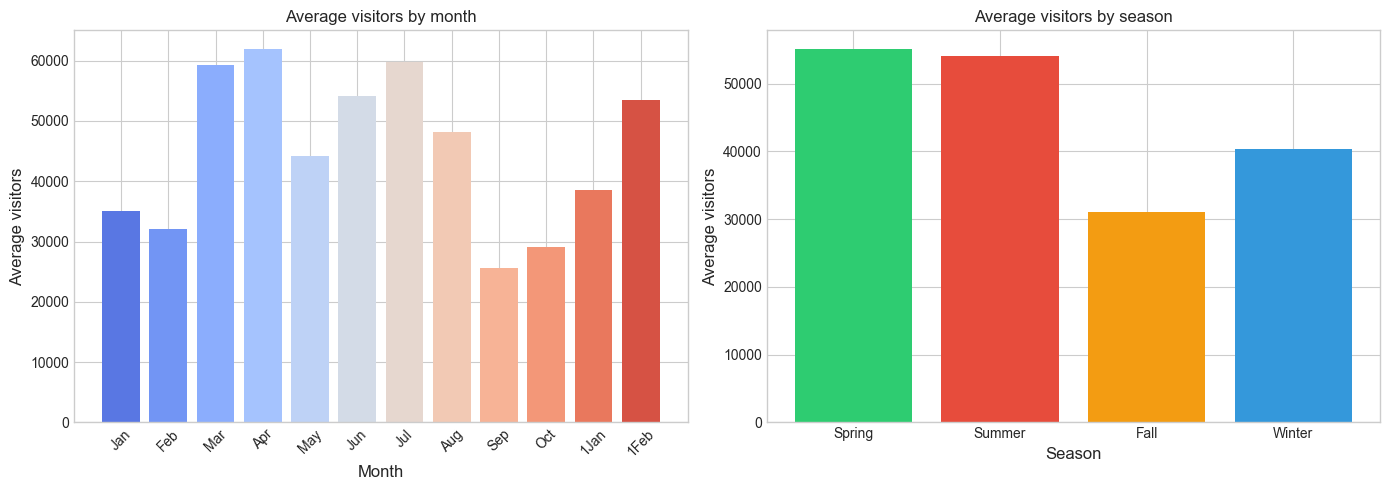

In [24]:
# 5. Seasonality analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Monthly average visitors
monthly_means = df.groupby('month')['visitors'].mean()
colors = plt.cm.coolwarm(np.linspace(0.1, 0.9, 12))
axes[0].bar(month_names, monthly_means, color=colors)
axes[0].set_xlabel('Month', fontsize=12)
axes[0].set_ylabel('Average visitors', fontsize=12)
axes[0].set_title('Average visitors by month')
axes[0].tick_params(axis='x', rotation=45)

# Season comparison
season_means = df.groupby('season')['visitors'].mean().reindex(['Spring', 'Summer', 'Fall', 'Winter'])
season_colors = ['#2ecc71', '#e74c3c', '#f39c12', '#3498db']
axes[1].bar(season_means.index, season_means, color=season_colors)
axes[1].set_xlabel('Season', fontsize=12)
axes[1].set_ylabel('Average visitors', fontsize=12)
axes[1].set_title('Average visitors by season')

plt.tight_layout()
plt.savefig('../images/seasonal_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

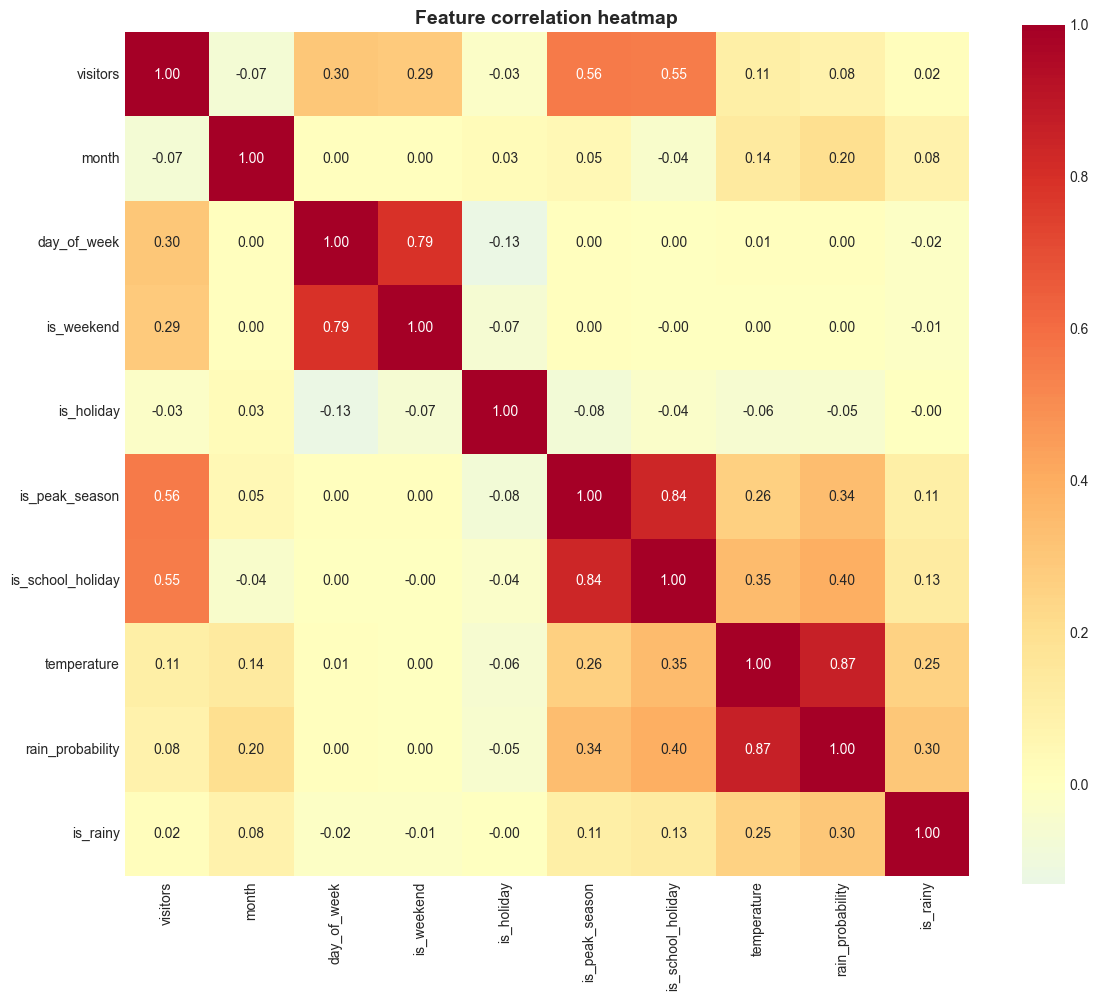

In [25]:
# 6. Correlation heatmap
fig, ax = plt.subplots(figsize=(12, 10))
correlation_matrix = df[numeric_columns].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='RdYlBu_r', center=0, 
            fmt='.2f', ax=ax, square=True)
ax.set_title('Feature correlation heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

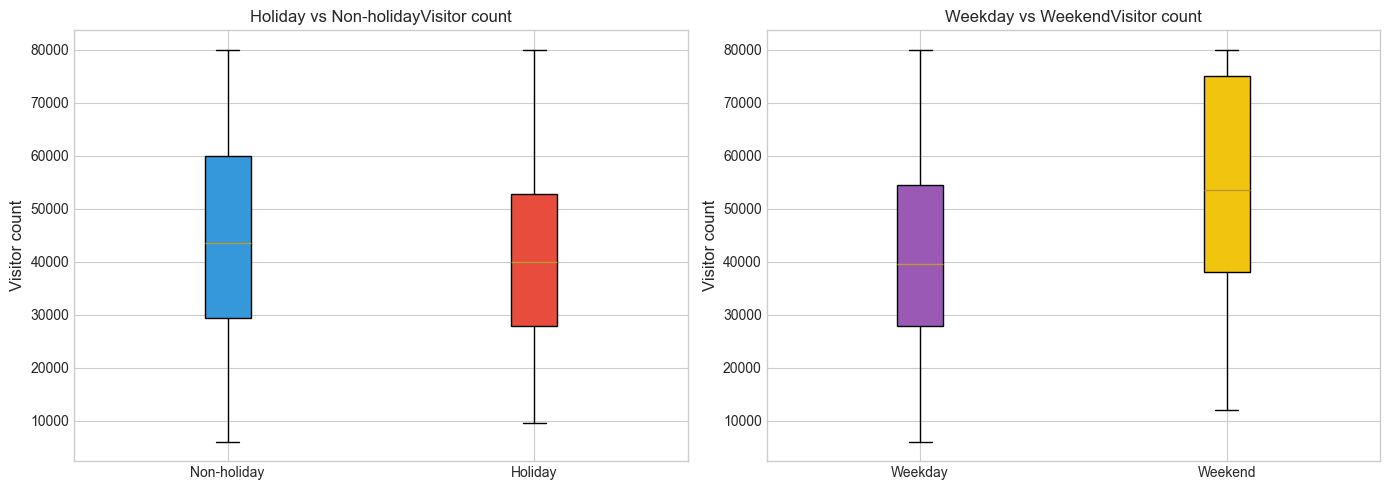

In [26]:
# 7. Holiday and weekend impact analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Holiday comparison
holiday_data = [df[df['is_holiday']==0]['visitors'], df[df['is_holiday']==1]['visitors']]
bp1 = axes[0].boxplot(holiday_data, labels=['Non-holiday', 'Holiday'], patch_artist=True)
bp1['boxes'][0].set_facecolor('#3498db')
bp1['boxes'][1].set_facecolor('#e74c3c')
axes[0].set_ylabel('Visitor count', fontsize=12)
axes[0].set_title('Holiday vs Non-holidayVisitor count')

# Weekend comparison
weekend_data = [df[df['is_weekend']==0]['visitors'], df[df['is_weekend']==1]['visitors']]
bp2 = axes[1].boxplot(weekend_data, labels=['Weekday', 'Weekend'], patch_artist=True)
bp2['boxes'][0].set_facecolor('#9b59b6')
bp2['boxes'][1].set_facecolor('#f1c40f')
axes[1].set_ylabel('Visitor count', fontsize=12)
axes[1].set_title('Weekday vs WeekendVisitor count')

plt.tight_layout()
plt.savefig('../images/holiday_weekend_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

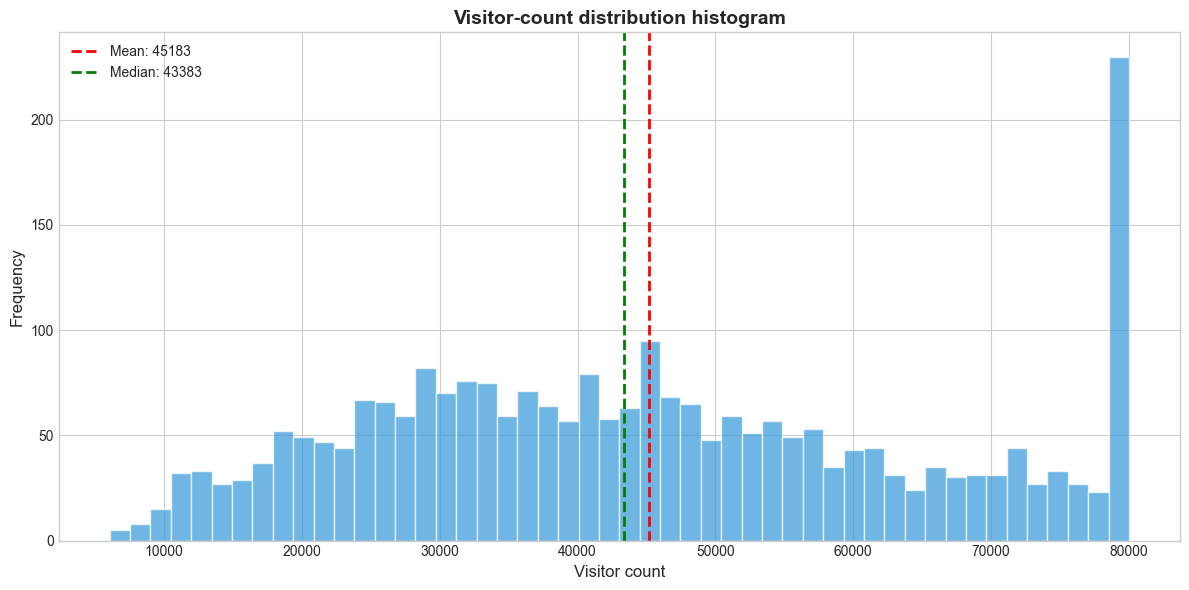

In [27]:
# 8. Visitor-count distribution histogram
fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(df['visitors'], bins=50, color='#3498db', edgecolor='white', alpha=0.7)
ax.axvline(df['visitors'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["visitors"].mean():.0f}')
ax.axvline(df['visitors'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {df["visitors"].median():.0f}')
ax.set_xlabel('Visitor count', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Visitor-count distribution histogram', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../images/visitors_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

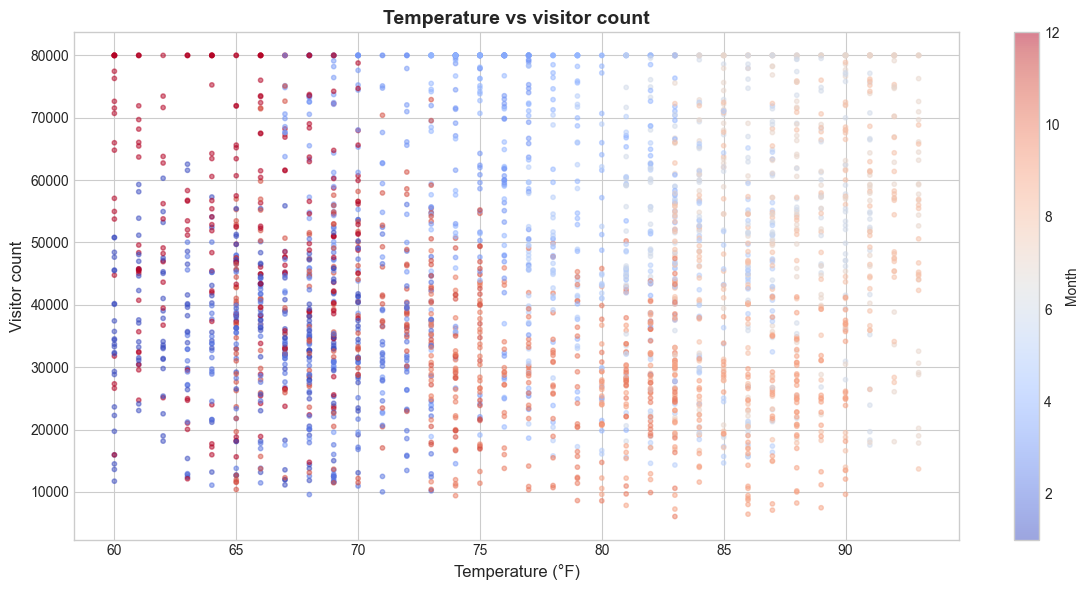

In [28]:
# 9. Temperature vs visitor count
fig, ax = plt.subplots(figsize=(12, 6))
scatter = ax.scatter(df['temperature'], df['visitors'], c=df['month'], 
                     cmap='coolwarm', alpha=0.5, s=10)
plt.colorbar(scatter, label='Month')
ax.set_xlabel('Temperature (°F)', fontsize=12)
ax.set_ylabel('Visitor count', fontsize=12)
ax.set_title('Temperature vs visitor count', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/temperature_visitors.png', dpi=150, bbox_inches='tight')
plt.show()

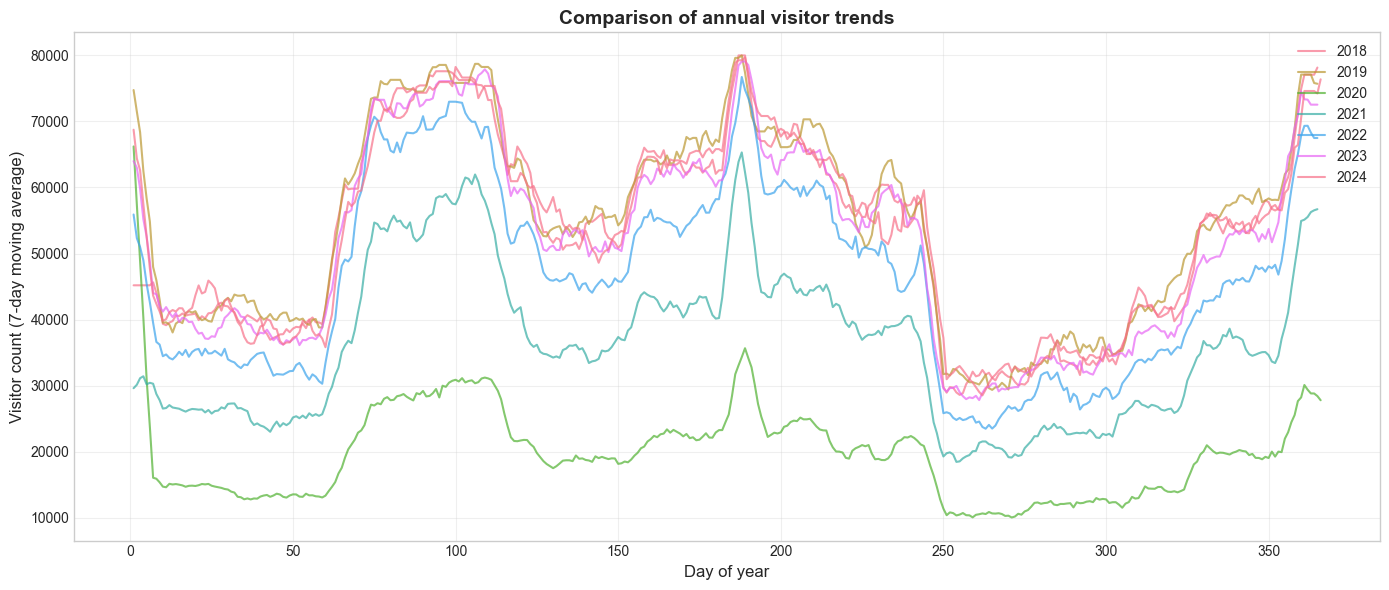

In [29]:
# 10. Annual trend comparison (excluding the 2020 pandemic effect)
fig, ax = plt.subplots(figsize=(14, 6))

for year in range(2018, 2025):
    year_data = df[df['year'] == year]
    ax.plot(year_data['day_of_year'], year_data['visitors_ma7'], 
            label=str(year), alpha=0.7, linewidth=1.5)

ax.set_xlabel('Day of year', fontsize=12)
ax.set_ylabel('Visitor count (7-day moving average)', fontsize=12)
ax.set_title('Comparison of annual visitor trends', fontsize=14, fontweight='bold')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../images/yearly_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Save Data

In [30]:
# Save processed data
output_path = '../data/processed/disney_attendance_cleaned.csv'
df.to_csv(output_path, index=False)
print(f"Cleaned data saved to: {output_path}")
print(f"Dataset shape: {df.shape}")

Cleaned data saved to: ../data/processed/disney_attendance_cleaned.csv
Dataset shape: (2557, 23)


In [31]:
# Summary report
print("=" * 60)
print("Disney visitor data analysis summary")
print("=" * 60)
print(f"\nDate range: {df['date'].min().strftime('%Y-%m-%d')} to {df['date'].max().strftime('%Y-%m-%d')}")
print(f"Total records: {len(df):,}")
print(f"\nVisitor count statistics:")
print(f"  - Mean: {df['visitors'].mean():,.0f} visitors/day")
print(f"  - Median: {df['visitors'].median():,.0f} visitors/day")
print(f"  - Min: {df['visitors'].min():,} visitors/day")
print(f"  - Max: {df['visitors'].max():,} visitors/day")
print(f"  - Std: {df['visitors'].std():,.0f}")
print(f"\nKey findings:")
print(f"  1. Peak month: {monthly_stats['Average visitors'].idxmax()} (average {monthly_stats['Average visitors'].max():,.0f} visitors)")
print(f"  2. Low month: {monthly_stats['Average visitors'].idxmin()} (average {monthly_stats['Average visitors'].min():,.0f} visitors)")
print(f"  3. Average weekend visitors: {df[df['is_weekend']==1]['visitors'].mean():,.0f} visitors")
print(f"  4. Average weekday visitors: {df[df['is_weekend']==0]['visitors'].mean():,.0f} visitors")
print(f"  5. Average holiday visitors: {df[df['is_holiday']==1]['visitors'].mean():,.0f} visitors")
print(f"  6. Average non-holiday visitors: {df[df['is_holiday']==0]['visitors'].mean():,.0f} visitors")
print("\n" + "=" * 60)

Disney visitor data analysis summary

Date range: 2018-01-01 to 2024-12-31
Total records: 2,557

Visitor count statistics:
  - Mean: 45,183 visitors/day
  - Median: 43,383 visitors/day
  - Min: 6,065 visitors/day
  - Max: 80,000 visitors/day
  - Std: 19,794

Key findings:
  1. Peak month: Apr (average 61,930 visitors)
  2. Low month: Sep (average 25,525 visitors)
  3. Average weekend visitors: 54,193 visitors
  4. Average weekday visitors: 41,584 visitors
  5. Average holiday visitors: 42,040 visitors
  6. Average non-holiday visitors: 45,290 visitors

